In [ ]:
pip install -r requirement-plate_regconition.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 86.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 20.8 MB/s eta 0:00:00


In [ ]:
import cv2
import numpy as np
import torch
from ultralytics import YOLO
from fast_plate_ocr import LicensePlateRecognizer

class ANPR:
    def __init__(self, model_path: str = "yolo11n.pt"):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = YOLO(model_path)

        # Đổi EasyOCR sang Fast Plate OCR
        # Lần đầu chạy nó sẽ tự tải model cct-s-v2-global-model về
        self.reader = LicensePlateRecognizer('cct-s-v2-global-model')

    def detect_plates(self, im0: np.ndarray):
        results = self.model.predict(im0, verbose=False)
        boxes = results[0].boxes.xyxy.cpu().numpy() if results and results[0].boxes is not None else []
        return boxes

    def extract_text(self, im0: np.ndarray, bbox: np.ndarray):
            x1, y1, x2, y2 = map(int, bbox)
            roi = im0[y1:y2, x1:x2]

            if roi.size == 0:
                return ""

            # Đưa ảnh roi vào model
            results = self.reader.run(roi)

            if not results:
                return ""

            # Lấy kết quả đầu tiên
            pred = results[0]

            # Tự động dò tìm thuộc tính chứa text
            if hasattr(pred, 'text'):
                return pred.text
            elif hasattr(pred, 'plate'):
                return pred.plate
            elif hasattr(pred, 'chars'):
                # Lỡ nó trả về list các ký tự thì nối lại
                return "".join(pred.chars) if isinstance(pred.chars, list) else pred.chars
            else:
                # Nếu vẫn không trúng cái nào, in toàn bộ ruột gan của object ra để soi
                print(f"Cảnh báo: Thuộc tính lạ trong PlatePrediction: {dir(pred)}")
                print(f"Giá trị thực tế: {vars(pred) if hasattr(pred, '__dict__') else pred}")
                # Trả về chuỗi ép kiểu tạm thời để code không bị văng lỗi (crash)
                return str(pred)

    def infer_video(self, source, output_path="output.mp4", display=False):
        print("Starting ANPR video inference...")

        cap = cv2.VideoCapture(source)
        if not cap.isOpened():
            raise ValueError(f"Cannot open video source: {source}")

        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps = int(cap.get(cv2.CAP_PROP_FPS)) or 30

        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        writer = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

        # Dùng try-except để không bị lỗi nếu chạy ở môi trường ngoài Colab
        try:
            from google.colab.patches import cv2_imshow
        except ImportError:
            pass

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            im0 = frame.copy()

            boxes = self.detect_plates(im0)

            for bbox in boxes:
                x1, y1, x2, y2 = map(int, bbox)

                # OCR với fast-plate-ocr
                text = self.extract_text(im0, bbox)

                # Draw bbox + text
                cv2.rectangle(im0, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(im0, text, (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

            writer.write(im0)

            # Debug (rất chậm trên Colab)
            if display:
                try:
                    cv2_imshow(im0)
                except NameError:
                    cv2.imshow("ANPR", im0)
                    if cv2.waitKey(1) & 0xFF == ord('q'):
                        break

        cap.release()
        writer.release()
        cv2.destroyAllWindows()

        print(f"Saved output to {output_path}")

    def infer_image(self, image_path: str, output_path: str = "output.jpg", display: bool = False):
            print(f"Starting ANPR image inference on {image_path}...")

            # 1. Đọc ảnh
            im0 = cv2.imread(image_path)
            if im0 is None:
                raise ValueError(f"Không thể đọc được ảnh từ đường dẫn: {image_path}")

            # 2. Detect vị trí biển số
            boxes = self.detect_plates(im0)

            # 3. Lặp qua từng biển số tìm được (nếu trong ảnh có nhiều xe)
            for bbox in boxes:
                x1, y1, x2, y2 = map(int, bbox)

                # OCR đọc chữ từ vùng đã crop
                text = self.extract_text(im0, bbox)

                # Vẽ khung chữ nhật và in chữ lên ảnh
                cv2.rectangle(im0, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(im0, text, (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

            # 4. Lưu ảnh kết quả
            cv2.imwrite(output_path, im0)
            print(f"Đã lưu ảnh kết quả tại {output_path}")

            # 5. Hiển thị ảnh (dùng cho Colab hoặc chạy local)
            if display:
                try:
                    from google.colab.patches import cv2_imshow
                    cv2_imshow(im0)
                except ImportError:
                    cv2.imshow("ANPR Result", im0)
                    cv2.waitKey(0) # Đợi bạn bấm phím bất kỳ để đóng cửa sổ
                    cv2.destroyAllWindows()

Starting ANPR image inference on 3.jpg...
Đã lưu ảnh kết quả tại result.jpg


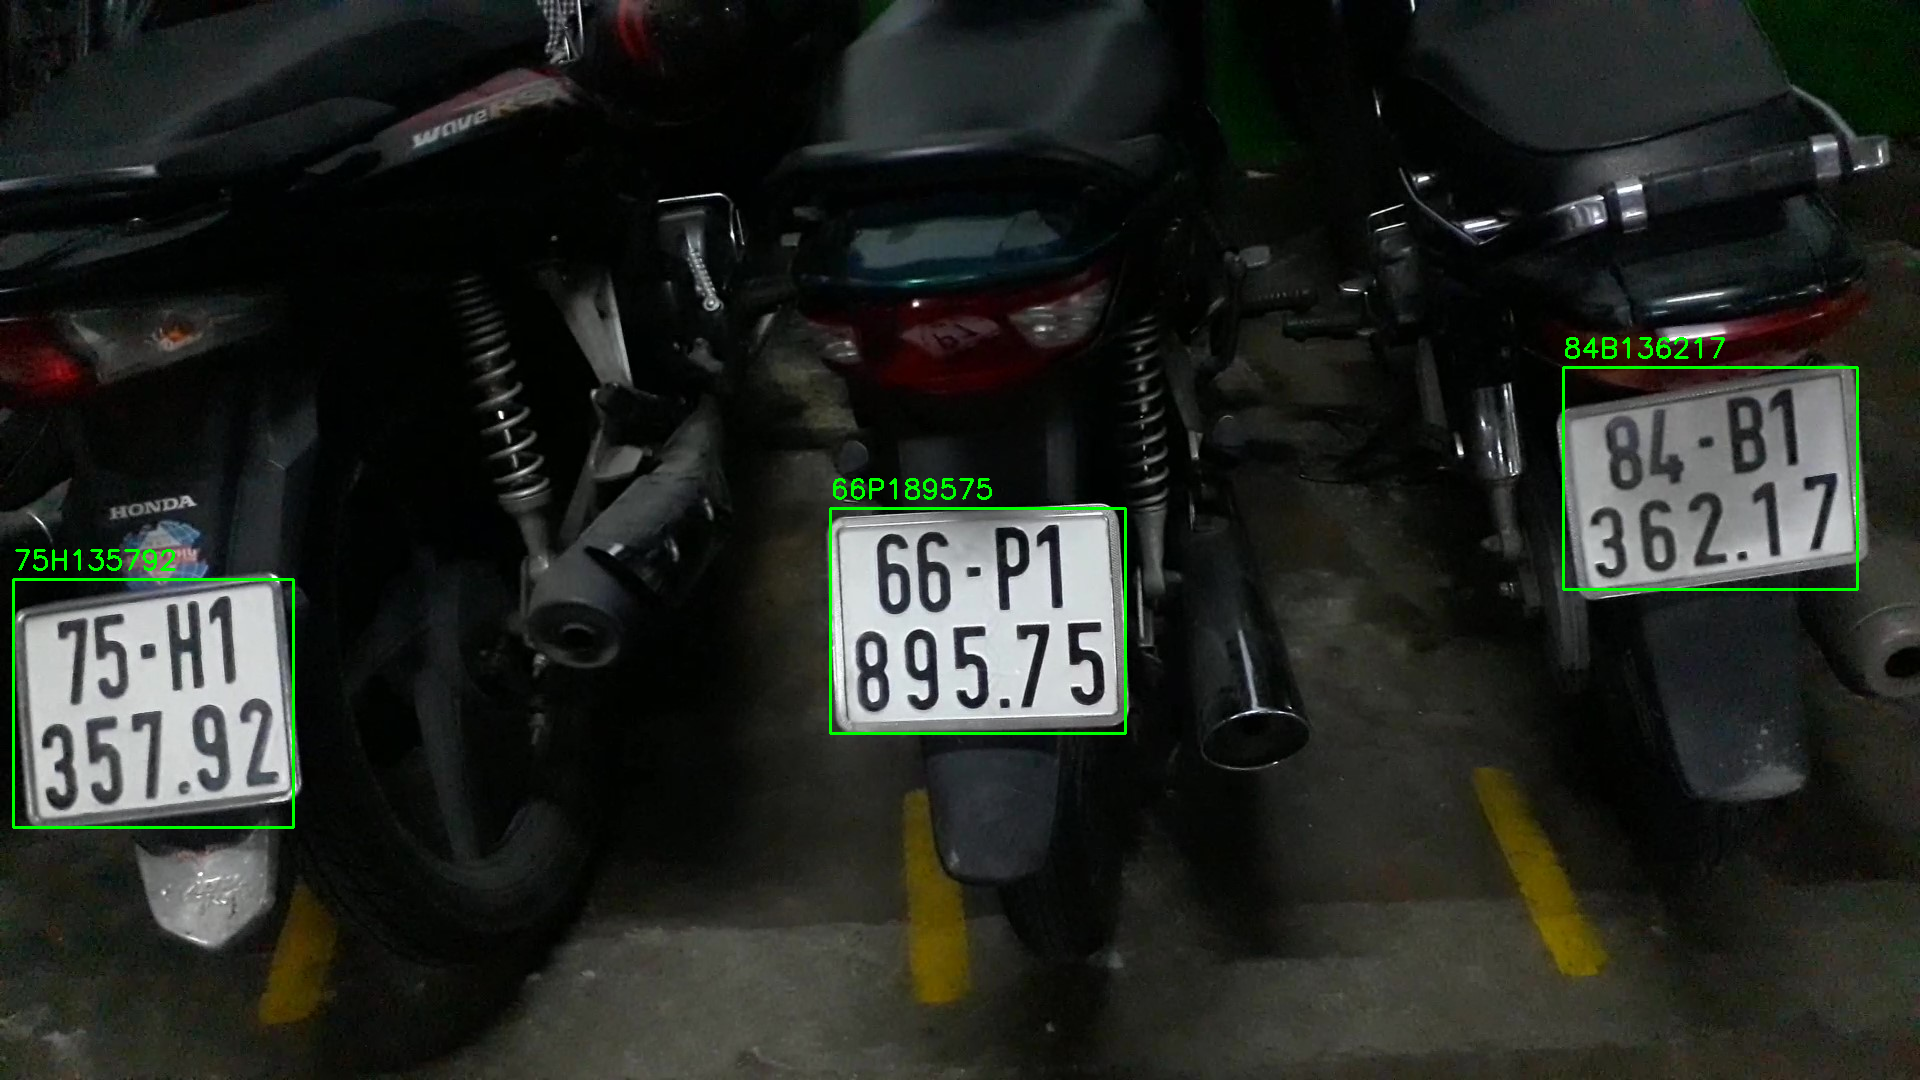

In [ ]:
# Khởi tạo class với model YOLO đã train của bạn
anpr = ANPR("anpr_best.pt")

# Chạy inference trên ảnh 3.jpg, xuất ra file kết quả và hiển thị luôn lên màn hình
anpr.infer_image("3.jpg", output_path="result.jpg", display=True)